## Check the typed file before we build on it

Every cell in this notebook reads one file: `fannie_2017_typed.parquet`. This confirms it has what we need before we build anything on top of it.

**What this checks**

- How many loans are in the file
- Whether all 18 model features are present, and what type each one is
- Whether the columns the LP and the rule-based scorer need made it through
- Where the nulls are, so our null rules match what is actually in the data
- What values sit in the two Y/N columns we are turning into flags

**Why it matters**

- Three of the 18 features do not exist yet. They get built from other columns. This confirms those source columns are there and hold what we expect.
- We are dropping rows with a missing DTI. This tells us how many that is before it changes the row count.
- Read only. Nothing is written or changed.

In [3]:
import polars as pl
from pathlib import Path

PROC = Path("../data/processed")
TYPED = PROC / "fannie_2017_typed.parquet"

lf = pl.scan_parquet(TYPED)
schema = lf.collect_schema()

# --- the 18 model features, grouped as decided ---
NUM  = ["CSCORE_B", "CSCORE_C", "OLTV", "DTI", "ORIG_UPB", "ORIG_TERM"]
CNT  = ["NUM_BO"]
FLG  = ["is_first_time", "is_homeready", "is_hfa",
        "has_coborrower", "is_high_balance", "is_relo"]
CATF = ["CHANNEL", "PURPOSE", "PROP", "OCC_STAT", "STATE"]

# --- columns the three missing flags get built FROM ---
FLAG_SOURCE = ["CSCORE_C", "HIGH_BALANCE_LOAN_INDICATOR",
               "RELOCATION_MORTGAGE_INDICATOR"]

# --- columns the LP, the scorer, and the pool file need ---
CARRY = ["LOAN_ID", "default_flag", "credit_grade",
         "interest_income_7yr", "loss_if_default", "lgd", "ORIG_RATE"]

print(f"file  : {TYPED}")
print(f"rows  : {lf.select(pl.len()).collect().item():,}")
print(f"cols  : {len(schema)}")

print("\n--- model features ---")
for group, cols in [("numeric", NUM), ("count", CNT),
                    ("flag", FLG), ("categorical", CATF)]:
    for c in cols:
        if c in schema:
            print(f"  {group:12} {c:36} {schema[c]}")
        else:
            print(f"  {group:12} {c:36} NOT IN FILE (must be built)")

print("\n--- source columns for the built flags ---")
for c in FLAG_SOURCE:
    print(f"  {c:38} {schema[c] if c in schema else 'MISSING'}")

print("\n--- carried through for the LP and the scorer ---")
for c in CARRY:
    print(f"  {c:38} {schema[c] if c in schema else 'MISSING'}")

# dict.fromkeys drops repeats while keeping order.
# CSCORE_C sits in both NUM and FLAG_SOURCE, and asking
# for the same column twice in one select is an error.
check = list(dict.fromkeys(
    c for c in NUM + CNT + CATF + FLAG_SOURCE + CARRY if c in schema
))

nulls = (
    lf.select([pl.col(c).null_count().alias(c) for c in check])
      .collect()
      .transpose(include_header=True, column_names=["nulls"])
      .filter(pl.col("nulls") > 0)
      .sort("nulls", descending=True)
)
print("\n--- columns with nulls (everything else is clean) ---")
with pl.Config(tbl_rows=-1):
    print(nulls)

print("\n--- values in the Y/N indicator columns ---")
for c in ["HIGH_BALANCE_LOAN_INDICATOR", "RELOCATION_MORTGAGE_INDICATOR"]:
    if c in schema:
        print(f"\n{c}")
        print(lf.select(c).collect()[c].value_counts(sort=True))

print("\n--- existing flags: distinct values ---")
for c in ["is_first_time", "is_homeready", "is_hfa"]:
    if c in schema:
        vals = lf.select(pl.col(c).unique()).collect()[c].to_list()
        print(f"  {c:20} {sorted(v for v in vals if v is not None)}")

if "DTI" in schema:
    n_dti = lf.select(pl.col("DTI").null_count()).collect().item()
    n_all = lf.select(pl.len()).collect().item()
    print(f"\nDTI nulls to drop: {n_dti:,}  ({n_dti/n_all:.4%} of the book)")

file  : ../data/processed/fannie_2017_typed.parquet
rows  : 2,046,851
cols  : 127

--- model features ---
  numeric      CSCORE_B                             Int32
  numeric      CSCORE_C                             Int32
  numeric      OLTV                                 Float64
  numeric      DTI                                  Float64
  numeric      ORIG_UPB                             Float64
  numeric      ORIG_TERM                            Float64
  count        NUM_BO                               Int32
  flag         is_first_time                        Int8
  flag         is_homeready                         Int8
  flag         is_hfa                               Int8
  flag         has_coborrower                       NOT IN FILE (must be built)
  flag         is_high_balance                      NOT IN FILE (must be built)
  flag         is_relo                              NOT IN FILE (must be built)
  categorical  CHANNEL                              String
  categori

## Build the model frame and reconcile the row count

One pass over the typed file that produces the frame everything else runs on, plus a report of exactly what changed and why.

**What it does**

- Builds the three flags that do not exist yet
  - `has_coborrower`: 1 when the loan has a second borrower with a credit score
  - `is_high_balance`: 1 when the Y/N column says Y
  - `is_relo`: 1 when the Y/N column says Y
- Applies the null rules we agreed on
  - `CSCORE_C` null becomes 0, with `has_coborrower` carrying the real meaning
  - `CSCORE_B` null gets the median score, no flag
  - `DTI` null means the row is dropped
- Keeps the 18 model features plus the columns the LP, the rule-based scorer, and the pool file need
- Prints the reconciliation: rows in, rows out, columns built, nulls filled

**Why the null rules are what they are**

- There is no co-borrower score to estimate when there is no co-borrower. The 0 is filler; the flag tells the model which loans it applies to.
- Missing credit scores get the median so those loans stay in the book. A lender still has to make a decision on an applicant with no score, and these loans default below the book average, so they are not junk. We tested a flag for them and it carried nothing.
- 340 rows is too few to model around, so they come out.

**Why the row count is settled here**

Every drop happens before the data is split. If we dropped rows later, train, calibration, and test would each lose a different slice and the numbers would be harder to explain.

**Read only on disk.** Nothing is written. The frame lives in the session.

In [5]:
import polars as pl
from pathlib import Path

pl.Config.set_tbl_rows(200)
pl.Config.set_tbl_cols(50)
pl.Config.set_fmt_str_lengths(60)
pl.Config.set_tbl_width_chars(200)

PROC = Path("../data/processed")
TYPED = PROC / "fannie_2017_typed.parquet"

# --- the 18 model features ---
NUM  = ["CSCORE_B", "CSCORE_C", "OLTV", "DTI", "ORIG_UPB", "ORIG_TERM", "NUM_BO"]
FLG  = ["is_first_time", "is_homeready", "is_hfa",
        "has_coborrower", "is_high_balance", "is_relo"]
CATF = ["CHANNEL", "PURPOSE", "PROP", "OCC_STAT", "STATE"]
FEATURES = NUM + FLG + CATF

# --- not modeled, but needed downstream ---
CARRY = ["LOAN_ID", "default_flag", "credit_grade",
         "interest_income_7yr", "loss_if_default", "lgd", "ORIG_RATE"]

raw = pl.scan_parquet(TYPED)

# counts taken before anything changes, so the reconciliation is exact
n_in       = raw.select(pl.len()).collect().item()
n_dti_null = raw.select(pl.col("DTI").null_count()).collect().item()
n_csc_null = raw.select(pl.col("CSCORE_C").null_count()).collect().item()
n_csb_null = raw.select(pl.col("CSCORE_B").null_count()).collect().item()
fico_median = raw.select(pl.col("CSCORE_B").median()).collect().item()

df = (
    raw
    # build the three missing flags off the ORIGINAL columns,
    # before any fill touches them
    .with_columns([
        pl.col("CSCORE_C").is_not_null().cast(pl.Int8).alias("has_coborrower"),
        (pl.col("HIGH_BALANCE_LOAN_INDICATOR") == "Y").cast(pl.Int8).alias("is_high_balance"),
        (pl.col("RELOCATION_MORTGAGE_INDICATOR") == "Y").cast(pl.Int8).alias("is_relo"),
    ])
    # then apply the null rules
    .with_columns([
        pl.col("CSCORE_C").fill_null(0),
        pl.col("CSCORE_B").fill_null(fico_median),
    ])
    .drop_nulls(subset=["DTI"])
    .select(CARRY + FEATURES)
    .collect()
)

n_out = len(df)

print("=" * 62)
print("RECONCILIATION")
print("=" * 62)

print(f"\nrows in  ({TYPED.name})            {n_in:>12,}")
print(f"dropped: DTI missing                       {-n_dti_null:>12,}")
print(f"rows out                                   {n_out:>12,}")
print(f"share of the book kept                     {n_out/n_in:>12.4%}")

print("\n--- columns built ---")
print(f"  has_coborrower    from CSCORE_C not null           {df['has_coborrower'].sum():>10,} flagged")
print(f"  is_high_balance   from HIGH_BALANCE_LOAN_INDICATOR {df['is_high_balance'].sum():>10,} flagged")
print(f"  is_relo           from RELOCATION_MORTGAGE_IND.    {df['is_relo'].sum():>10,} flagged")

print("\n--- nulls filled ---")
print(f"  CSCORE_C   filled with 0                {n_csc_null:>12,}  ({n_csc_null/n_in:.2%} of the book)")
print(f"             meaning: no co-borrower, has_coborrower carries it")
print(f"  CSCORE_B   filled with median {fico_median:<6}    {n_csb_null:>12,}  ({n_csb_null/n_in:.4%} of the book)")
print(f"             no flag: tested at odds ratio 1.018, carried nothing")

print("\n--- features excluded on purpose ---")
print("  ORIG_RATE   priced off the same risk we predict (carried for the LP, not modeled)")
print("  SELLER      lender identity, not borrower risk")
print("  OCLTV       0.98 correlated with OLTV")
print("  MI_PCT      nearly a restatement of LTV above 80")
print("  MI_TYPE     who pays the insurance carried nothing")
print("  NO_UNITS    absorbed by OCC_STAT")
print("  second_lien odds ratio 1.074, no independent signal")
print("  PROPERTY_INSPECTION_WAIVER   column is empty in the 2017 book")

print("\n" + "=" * 62)
print("VERIFICATION")
print("=" * 62)

remaining = (
    df.select([pl.col(c).null_count().alias(c) for c in df.columns])
      .transpose(include_header=True, column_names=["nulls"])
      .filter(pl.col("nulls") > 0)
)
print(f"\nnulls remaining anywhere: {remaining.height} columns")
if remaining.height:
    print(remaining)

print(f"\nfeature count : {len(FEATURES)}  ({len(NUM)} numeric, {len(FLG)} flags, {len(CATF)} categorical)")
print(f"frame shape   : {df.shape}")
print(f"memory        : {df.estimated_size('mb'):.0f} MB")
print(f"default rate  : {df['default_flag'].mean():.6f}")

print("\n--- new flags: distinct values (must be 0 and 1 only) ---")
for c in ["has_coborrower", "is_high_balance", "is_relo"]:
    print(f"  {c:18} {sorted(df[c].unique().to_list())}")

print("\n--- CSCORE_C after fill, split by whether a co-borrower exists ---")
print(
    df.group_by("has_coborrower")
      .agg(
          pl.len().alias("n"),
          pl.col("CSCORE_C").min().alias("min"),
          pl.col("CSCORE_C").max().alias("max"),
          pl.col("default_flag").mean().round(4).alias("default_rate"),
      )
      .sort("has_coborrower")
)

RECONCILIATION

rows in  (fannie_2017_typed.parquet)               2,046,851
dropped: DTI missing                               -340
rows out                                      2,046,511
share of the book kept                         99.9834%

--- columns built ---
  has_coborrower    from CSCORE_C not null              963,672 flagged
  is_high_balance   from HIGH_BALANCE_LOAN_INDICATOR     53,347 flagged
  is_relo           from RELOCATION_MORTGAGE_IND.        13,166 flagged

--- nulls filled ---
  CSCORE_C   filled with 0                   1,083,143  (52.92% of the book)
             meaning: no co-borrower, has_coborrower carries it
  CSCORE_B   filled with median 759.0            1,573  (0.0768% of the book)
             no flag: tested at odds ratio 1.018, carried nothing

--- features excluded on purpose ---
  ORIG_RATE   priced off the same risk we predict (carried for the LP, not modeled)
  SELLER      lender identity, not borrower risk
  OCLTV       0.98 correlated with OLT

## Finding: the frame is clean and the co-borrower filler is safe

- 2,046,511 loans, 25 columns, no nulls anywhere. 340 rows dropped for missing DTI, 99.98% of the book kept.
- Default rate 3.4133%, unchanged from the full book.
- All three new flags came out 0/1. Counts reconcile: high balance 53,388 to 53,347 and no-coborrower 1,083,143 to 1,082,839, both differences inside the 340 dropped rows.
- **Filling the co-borrower score with 0 is safe.** Real co-borrower scores run 620 to 839. The filler sits at 0, a 620 point gap below the lowest real value, so a tree separates them on the first split and never reads the filler as a bad credit score. This is why 0 works here and would not have worked for the main credit score, where a filler would land inside the real range.
- Loans with a co-borrower default at 2.36%. Loans without one default at 4.35%, nearly double. `has_coborrower` is carrying real signal, not just marking the filler.
- Two items for the report: our row count is 2,046,511 against the EDA track's 2,044,946, and `NUM_BO` is grouped with the numerics here rather than counted separately.

## Assign the split

Divide the loans into three groups: one to train on, one held back for calibration work, one held back to report final numbers.

**What it does**

- Sorts each loan into train, calibration, or test at 60/20/20
- Assigns by running `LOAN_ID` through a hash and taking the last two digits, rather than shuffling
- Prints the size and default rate of each group

**Why hash instead of shuffle**

- The same loan lands in the same group every run, on any machine. No stored seed, no saved file, nothing to go stale.
- A teammate reruns this cell and gets identical groups.

**Why the split happens here**

Every row we were going to drop is already gone. The three groups divide a settled book, so the counts add up and stay that way.

**Not exactly balanced, and that is fine**

Random assignment lets the default rate drift slightly between groups. We check it below rather than force it. If the three rates sit close together, nothing downstream cares.

In [6]:
SEED = 591

df = (
    df.with_columns((pl.col("LOAN_ID").hash(seed=SEED) % 100).alias("_bucket"))
      .with_columns(
          pl.when(pl.col("_bucket") < 60).then(pl.lit("train"))
            .when(pl.col("_bucket") < 80).then(pl.lit("calib"))
            .otherwise(pl.lit("test"))
            .alias("split")
      )
      .drop("_bucket")
)

print("--- split sizes and default rate ---")
print(
    df.group_by("split")
      .agg(
          pl.len().alias("n"),
          (pl.len() / len(df)).round(4).alias("share"),
          pl.col("default_flag").sum().alias("defaults"),
          pl.col("default_flag").mean().round(6).alias("default_rate"),
      )
      .sort("split")
)

rates = df.group_by("split").agg(pl.col("default_flag").mean())["default_flag"]
print(f"\nbook default rate      : {df['default_flag'].mean():.6f}")
print(f"spread across splits   : {rates.max() - rates.min():.6f}")
print(f"rows accounted for     : {df['split'].is_not_null().sum():,} of {len(df):,}")

print("\n--- test pool, what the LP will draw from ---")
test = df.filter(pl.col("split") == "test")
print(f"  loans        : {len(test):,}")
print(f"  total UPB    : ${test['ORIG_UPB'].sum()/1e9:,.2f}B")
print(f"  states       : {test['STATE'].n_unique()}")

--- split sizes and default rate ---
shape: (3, 5)
┌───────┬─────────┬────────┬──────────┬──────────────┐
│ split ┆ n       ┆ share  ┆ defaults ┆ default_rate │
│ ---   ┆ ---     ┆ ---    ┆ ---      ┆ ---          │
│ str   ┆ u32     ┆ f64    ┆ i64      ┆ f64          │
╞═══════╪═════════╪════════╪══════════╪══════════════╡
│ calib ┆ 409280  ┆ 0.2    ┆ 14089    ┆ 0.034424     │
│ test  ┆ 409857  ┆ 0.2003 ┆ 13974    ┆ 0.034095     │
│ train ┆ 1227374 ┆ 0.5997 ┆ 41791    ┆ 0.034049     │
└───────┴─────────┴────────┴──────────┴──────────────┘

book default rate      : 0.034133
spread across splits   : 0.000375
rows accounted for     : 2,046,511 of 2,046,511

--- test pool, what the LP will draw from ---
  loans        : 409,857
  total UPB    : $93.76B
  states       : 54


## What the models are actually doing

**The label.** Every loan gets a 0 or a 1. A 1 means the loan hit our default definition: 180 days delinquent, or ended in a credit event disposition. A 0 means it did not. That flag is `default_flag`, and it is built from the loan's full payment history in the Fannie Mae data.

So this is binary classification. Two classes, default and no default. 3.41% of the book is a 1.

**But we never ask the model to pick a class.** This is the part that caused confusion last time.

A classifier can answer two different questions:

- `.predict()` gives a yes or no. Will this loan default?
- `.predict_proba()` gives a number between 0 and 1. How likely is this loan to default?

We only ever call `.predict_proba()`. Every model in this notebook is scored with `.predict_proba(X)[:, 1]`, which pulls the probability of class 1. That number is the loan's probability of default, or PD.

**Why we never threshold.** There is no confusion matrix in this project, no accuracy, no precision or recall, no cutoff at 0.5. Those all require converting the probability into a yes or no, and we never do that.

The reason is what happens next. The linear program computes each loan's expected return:

```
expected return = (1 - PD) x interest_income_7yr  -  PD x loss_if_default
```

That is arithmetic on the PD value itself. Not on its rank, not on a yes/no. Feed it a PD of 0.08 when the truth is 0.05 and every dollar figure downstream is wrong.

**Which is why we measure two different things.**

- **AUC** measures ranking. Does the model put riskier loans above safer ones?
- **Calibration** measures the numbers themselves. Of all the loans the model called 8%, did about 8 out of 100 actually default?

A model can rank perfectly and still be uniformly double the truth. AUC would never catch it. The LP would.

Most classification projects only need AUC. Ours needs both, the calibration ensures the predicted probabilites are honest.

**What we are using**

| Piece | What it does |
|---|---|
| `LogisticRegression` | The linear baseline. Everything else has to beat it. |
| `XGBClassifier`, `LGBMClassifier`, `CatBoostClassifier` | Gradient-boosted trees. All three follow the scikit-learn interface, so `.fit()` and `.predict_proba()` work the same way on each. |
| `ColumnTransformer` + `OneHotEncoder` + `StandardScaler` | Prep for logistic regression only. The tree libraries read the categorical columns directly. |
| `roc_auc_score` | AUC. |
| `brier_score_loss` | Squared error on the probabilities. Rewards ranking and calibration together. |

**The output of this whole stage** is one file: the test-split loans with a PD attached to each one. That file is what the linear program reads. Nothing else from here moves forward.

## Logistic regression baseline

The simplest model on the list, fit first so everything after it has something to beat.

**What it does**

- Splits the frame into the three groups and hands scikit-learn the 18 features
- Turns the five text columns into 0/1 columns, one per value
- Puts the numeric columns on a common scale
- Fits the model and reports how well it separates defaults from non-defaults

**Why this one first**

- If the tree models cannot beat a straight line through the data, something is wrong with how they are set up, not with the trees.
- It is the only model that needs the text columns converted. Building it here proves that step works before anything else depends on it.

**Two setup choices**

- **Scaling the numerics.** Logistic regression is sensitive to the size of the numbers. Loan amount runs around $200,000 and debt-to-income runs around 35. Left alone, the loan amount would drown out everything else.
- **Grouping rare values.** Any text value appearing fewer than 100 times gets pooled into a single "infrequent" category. A value that shows up 60 times across 1.2 million loans cannot support its own column.

**How to read the score**

AUC answers one question: pick a loan that defaulted and a loan that did not, at random. How often does the model rate the defaulter as riskier? 0.5 is a coin flip. Mortgage models usually land between 0.75 and 0.80.

**The gap matters too.** We report the score on loans the model studied and on loans it never saw. A big difference between them means it memorized instead of learned.

In [7]:
import time
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

def xy(split_name):
    """Pull one split out of the frame as a scikit-learn matrix plus labels."""
    d = df.filter(pl.col("split") == split_name)
    X = d.select(FEATURES).to_pandas()
    for c in CATF:
        X[c] = X[c].astype("category")
    return X, d["default_flag"].to_numpy()

t = time.time()
X_tr, y_tr = xy("train")
X_ca, y_ca = xy("calib")
X_te, y_te = xy("test")
print(f"matrices : {time.time()-t:5.1f}s")
print(f"  train {X_tr.shape}   defaults {y_tr.sum():,}")
print(f"  calib {X_ca.shape}   defaults {y_ca.sum():,}")
print(f"  test  {X_te.shape}   defaults {y_te.sum():,}")

pre = ColumnTransformer([
    ("num", StandardScaler(), NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True,
                          min_frequency=100), CATF),
    ("flg", "passthrough", FLG),
])

logreg = Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=1000))])

t = time.time()
logreg.fit(X_tr, y_tr)
width = logreg.named_steps["pre"].transform(X_tr[:5]).shape[1]
print(f"\nfit      : {time.time()-t:5.1f}s   columns after encoding: {width}")

p_tr_lr = logreg.predict_proba(X_tr)[:, 1]
p_te_lr = logreg.predict_proba(X_te)[:, 1]

auc_tr = roc_auc_score(y_tr, p_tr_lr)
auc_te = roc_auc_score(y_te, p_te_lr)

print(f"\n--- logistic regression ---")
print(f"  AUC on loans it studied  : {auc_tr:.4f}")
print(f"  AUC on loans it never saw: {auc_te:.4f}")
print(f"  gap                      : {auc_tr - auc_te:.4f}")
print(f"\n  average prediction       : {p_te_lr.mean():.6f}")
print(f"  actual default rate      : {y_te.mean():.6f}")

matrices :   0.2s
  train (1227374, 18)   defaults 41,791
  calib (409280, 18)   defaults 14,089
  test  (409857, 18)   defaults 13,974

fit      :   3.3s   columns after encoding: 80

--- logistic regression ---
  AUC on loans it studied  : 0.7686
  AUC on loans it never saw: 0.7666
  gap                      : 0.0020

  average prediction       : 0.034170
  actual default rate      : 0.034095


## Finding: logistic regression sets the floor at 0.7666

- Test AUC 0.7666. Gap between studied and unseen loans is 0.0020, so the model learned rather than memorized, even across 80 encoded columns.
- Average prediction 0.034170 against an actual 0.034095. The model is right on the overall rate.
- **Cutting five features cost 0.0015 of AUC.** The scaffold scored 0.7681 on 23 features; we score 0.7666 on 18. Those five were carrying almost nothing the remaining 18 do not already hold.
- This is the number the tree models have to beat. If they cannot, the problem is how they are set up, not the trees.

## The three tree models

XGBoost, LightGBM, and CatBoost, untuned, same settings as the scaffold.

- All three in one cell so the comparison reads as one table.
- No tuning yet. That comes after we pick a model.
- No early stopping. It would need the calibration group, and that group is reserved.
- No adjusting for the rare outcome. Those tricks distort the predicted probabilities, and the optimizer does math on those numbers.

Watch the gap between studied and unseen loans. Logistic regression came in at 0.0020. Above about 0.02 means the model is leaning on rows it saw.

In [8]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

t = time.time()
xgb = XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    tree_method="hist", enable_categorical=True,
    eval_metric="auc", n_jobs=-1, random_state=SEED,
)
xgb.fit(X_tr, y_tr)
p_tr_xgb = xgb.predict_proba(X_tr)[:, 1]
p_te_xgb = xgb.predict_proba(X_te)[:, 1]
print(f"xgboost  : {time.time()-t:5.1f}s")

t = time.time()
lgbm = LGBMClassifier(
    n_estimators=400, learning_rate=0.05, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8,
    n_jobs=-1, random_state=SEED, verbose=-1,
)
lgbm.fit(X_tr, y_tr, categorical_feature=CATF)
p_tr_lgb = lgbm.predict_proba(X_tr)[:, 1]
p_te_lgb = lgbm.predict_proba(X_te)[:, 1]
print(f"lightgbm : {time.time()-t:5.1f}s")

t = time.time()
cat = CatBoostClassifier(
    iterations=400, learning_rate=0.05, depth=6,
    cat_features=CATF, random_seed=SEED, verbose=0,
)
cat.fit(X_tr, y_tr)
p_tr_cat = cat.predict_proba(X_tr)[:, 1]
p_te_cat = cat.predict_proba(X_te)[:, 1]
print(f"catboost : {time.time()-t:5.1f}s")

# every model's predictions in one place, reused by the cells that follow
preds_tr = {"logreg": p_tr_lr, "xgboost": p_tr_xgb,
            "lightgbm": p_tr_lgb, "catboost": p_tr_cat}
preds_te = {"logreg": p_te_lr, "xgboost": p_te_xgb,
            "lightgbm": p_te_lgb, "catboost": p_te_cat}

print("\n" + "=" * 60)
print(f"{'model':12} {'studied':>9} {'unseen':>9} {'gap':>9} {'avg pred':>10}")
print("=" * 60)
for name in preds_te:
    a_tr = roc_auc_score(y_tr, preds_tr[name])
    a_te = roc_auc_score(y_te, preds_te[name])
    print(f"{name:12} {a_tr:9.4f} {a_te:9.4f} {a_tr-a_te:9.4f} "
          f"{preds_te[name].mean():10.6f}")
print("=" * 60)
print(f"{'actual':12} {'':9} {'':9} {'':9} {y_te.mean():10.6f}")

xgboost  :   5.4s
lightgbm :  10.1s
catboost :  55.3s

model          studied    unseen       gap   avg pred
logreg          0.7686    0.7666    0.0020   0.034170
xgboost         0.8068    0.7747    0.0320   0.034051
lightgbm        0.8254    0.7737    0.0517   0.033968
catboost        0.7777    0.7717    0.0060   0.034014
actual                                       0.034095


## Finding: four algorithms, one AUC ceiling

AUC is how often the model rates a loan that defaulted as riskier than one that did not. 0.5 is a coin flip.

| Model | Test AUC | Train AUC | Gap |
|---|---|---|---|
| Logistic regression | 0.7666 | 0.7686 | 0.0020 |
| XGBoost | 0.7747 | 0.8068 | 0.0320 |
| LightGBM | 0.7737 | 0.8254 | 0.0517 |
| CatBoost | 0.7717 | 0.7777 | 0.0060 |

- All four test AUCs land inside 0.008 of each other. Four different algorithms hitting the same wall means the limit is the data, not the method.
- XGBoost has the best test AUC but the second-worst gap. Its 0.0320 is five times CatBoost's 0.0060. LightGBM overfits hardest at 0.0517 and still scores lower than XGBoost on test.
- CatBoost gives up 0.0030 of test AUC to XGBoost and takes back a five-fold smaller gap.
- Every model's average predicted probability sits within 0.0002 of the actual 3.41% default rate.
- The AUC ordering is unchanged from the scaffold run on 23 features. Dropping five features moved the standings not at all.

## Calibration

**Calibration** asks whether the predicted probabilities are right as numbers, not just as rankings. Of all the loans a model called 8%, did about 8 out of 100 actually default?

**How the table is built.** Sort the test predictions from low to high, cut them into 10 equal-count bins, and for each bin compare what the model predicted against what actually happened.

- `pred` is the average prediction in the bin
- `obs` is the observed default rate in the bin
- `gap` is `obs - pred`. Negative means the model overpredicted risk, positive means it underpredicted

**Why equal-count bins and not evenly spaced ones.** At a 3.4% default rate, cutting 0 to 1 into ten equal slices puts almost every loan in the first bin and leaves nine empty. Equal-count bins put about 41,000 loans in each, so every bin is measurable.

**Two metrics**

- **ECE** (expected calibration error): the average gap between predicted and observed, weighted by bin size. Lower is better. This is the number that decides the model.
- **Brier**: mean squared error on the probabilities. Rewards ranking and calibration together, useful as a tiebreak.

**ECE has a floor.** With about 41,000 loans per bin, random sampling noise alone moves the observed rate by roughly 0.0008. So a perfect model would still score around 0.0006 here. Anything at that level cannot be distinguished from perfect on this test set.

In [9]:
from sklearn.metrics import brier_score_loss

def calib_table(y, p, name, bins=10):
    """Bin predictions into equal counts and compare predicted to observed."""
    q = np.quantile(p, np.linspace(0, 1, bins + 1))
    q[0], q[-1] = -np.inf, np.inf
    idx = np.digitize(p, q[1:-1])

    rows = [(b, (idx == b).sum(), p[idx == b].mean(), y[idx == b].mean())
            for b in range(bins)]

    t = pl.DataFrame(rows, schema=["bin", "n", "pred", "obs"], orient="row")
    t = t.with_columns([
        pl.col("pred").round(4),
        pl.col("obs").round(4),
        (pl.col("obs") - pl.col("pred")).round(4).alias("gap"),
    ])
    ece = float((t["n"] / t["n"].sum() * (t["obs"] - t["pred"]).abs()).sum())

    print(f"\n{name:10} ECE {ece:.5f}   Brier {brier_score_loss(y, p):.6f}   "
          f"AUC {roc_auc_score(y, p):.4f}")
    print(t)
    return t, ece

tables, eces = {}, {}
for name, p in preds_te.items():
    tables[name], eces[name] = calib_table(y_te, p, name)

print("\n" + "=" * 46)
print("ECE ranking (lower is better, floor is ~0.0006)")
print("=" * 46)
for name, e in sorted(eces.items(), key=lambda kv: kv[1]):
    print(f"  {name:10} {e:.5f}")

print("\n--- top bin: the riskiest 10% of loans ---")
print("This is where the LP makes its hardest calls.")
for name in preds_te:
    top = tables[name].row(9, named=True)
    direction = "over " if top["gap"] < 0 else "under"
    print(f"  {name:10} pred {top['pred']:.4f}   obs {top['obs']:.4f}   "
          f"{direction} by {abs(top['gap'])/top['pred']:.1%}")


logreg     ECE 0.00077   Brier 0.031619   AUC 0.7666
shape: (10, 5)
┌─────┬───────┬────────┬────────┬─────────┐
│ bin ┆ n     ┆ pred   ┆ obs    ┆ gap     │
│ --- ┆ ---   ┆ ---    ┆ ---    ┆ ---     │
│ i64 ┆ i64   ┆ f64    ┆ f64    ┆ f64     │
╞═════╪═══════╪════════╪════════╪═════════╡
│ 0   ┆ 40986 ┆ 0.0033 ┆ 0.0025 ┆ -0.0007 │
│ 1   ┆ 40986 ┆ 0.0065 ┆ 0.0063 ┆ -0.0002 │
│ 2   ┆ 40985 ┆ 0.0098 ┆ 0.0093 ┆ -0.0004 │
│ 3   ┆ 40986 ┆ 0.0136 ┆ 0.0136 ┆ 0.0     │
│ 4   ┆ 40985 ┆ 0.0183 ┆ 0.0191 ┆ 0.0008  │
│ 5   ┆ 40986 ┆ 0.0244 ┆ 0.0254 ┆ 0.001   │
│ 6   ┆ 40986 ┆ 0.0327 ┆ 0.0329 ┆ 0.0003  │
│ 7   ┆ 40985 ┆ 0.0449 ┆ 0.0455 ┆ 0.0006  │
│ 8   ┆ 40986 ┆ 0.0651 ┆ 0.0659 ┆ 0.0008  │
│ 9   ┆ 40986 ┆ 0.1232 ┆ 0.1204 ┆ -0.0029 │
└─────┴───────┴────────┴────────┴─────────┘

xgboost    ECE 0.00101   Brier 0.031510   AUC 0.7747
shape: (10, 5)
┌─────┬───────┬────────┬────────┬─────────┐
│ bin ┆ n     ┆ pred   ┆ obs    ┆ gap     │
│ --- ┆ ---   ┆ ---    ┆ ---    ┆ ---     │
│ i64 ┆ i64   ┆ f64    ┆ f

## Finding: all four models are calibrated, and the differences are noise

A calibrated model's numbers can be trusted as numbers. When it says 8%, roughly 8 out of 100 of those loans actually default. ECE is how we measure that: the average gap between what a model predicted and what actually happened. Lower is better, and 0 is perfect.

| Model | ECE | Brier | Test AUC |
|---|---|---|---|
| CatBoost | 0.00072 | 0.031523 | 0.7717 |
| Logistic regression | 0.00077 | 0.031619 | 0.7666 |
| LightGBM | 0.00093 | 0.031518 | 0.7737 |
| XGBoost | 0.00101 | 0.031510 | 0.7747 |

- All four are close to perfect. An ECE of 0.001 against a 3.4% default rate means the average prediction is off by a tenth of a percentage point.
- **The ranking above is not a real separation.** Best to worst is 0.0003, which is smaller than the measurement error on this test set. Brier ties all four at the fifth decimal.
- This is expected. All four models are trained on log-loss, which is lowest exactly when the predicted probability equals the true one. Calibration is what training was already asking for.
- **The riskiest 10% of loans is where they actually differ.** Logistic regression, XGBoost, and LightGBM all overstate risk there by 2.4% to 3.0%. CatBoost understates by 1.7%. It is the only model that does not overpredict where the LP makes its hardest funding calls.
- **What this means for model selection.** Calibration does not decide it. All four are usable and none is measurably better. The train-test gap is the only place the models separate, and CatBoost leads there by 5x.
- **One caveat for the report.** Train and test come from the same 2017 pool, so they look alike. A real lender trains on old loans and scores new applicants in a different economy. These models are calibrated on this split, not calibrated in general.

## Reliability curve

The calibration table, plotted. Same numbers, easier to read.

**Left panel.** Predicted against observed. Perfect calibration is the diagonal line. Points below it mean the model overpredicted risk, above means it underpredicted. Both axes are on log scales because eight of the ten bins sit below 5%, and a linear plot would crush them into the corner.

**Right panel.** The raw gap, observed minus predicted. Flat at zero is perfect. This is the panel that shows where the models actually differ.

**Why the raw gap and not a ratio.** A ratio would make a 0.0008 miss on a 0.003 prediction look catastrophic and a 0.0034 miss on a 0.128 prediction look fine. The LP multiplies PD by dollars, so only the size of the error matters, not the percentage. The gap is the honest view.

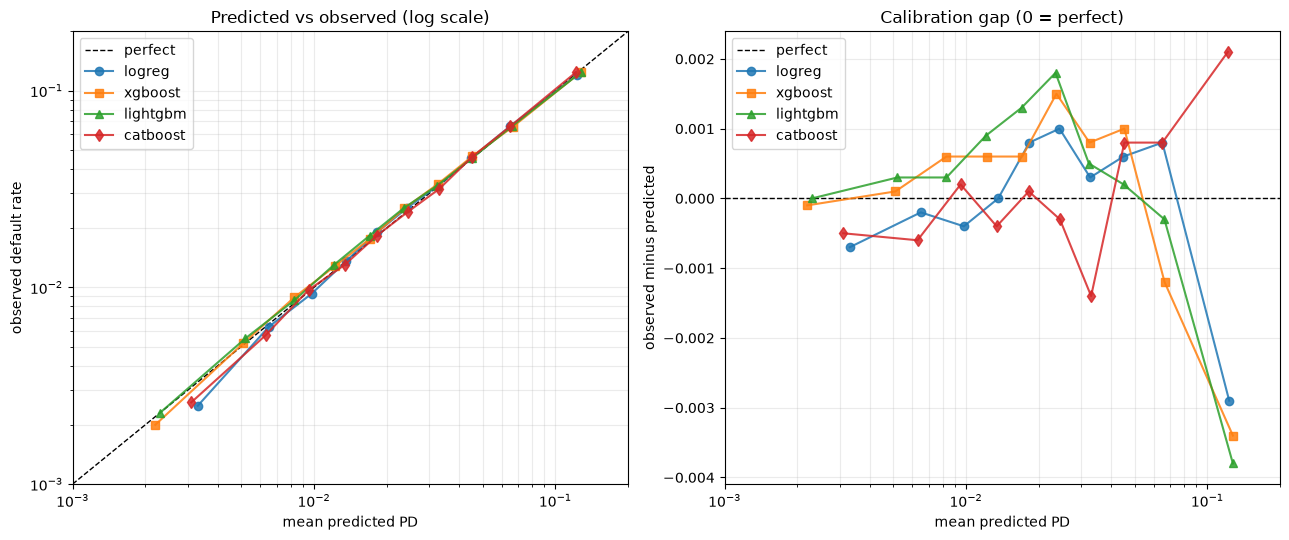

In [10]:
import matplotlib.pyplot as plt

MARK = {"logreg": "o-", "xgboost": "s-", "lightgbm": "^-", "catboost": "d-"}

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))

lims = (1e-3, 0.20)
a = ax[0]
a.plot(lims, lims, "k--", lw=1, label="perfect")
for name, t in tables.items():
    a.plot(t["pred"], t["obs"], MARK[name], label=name, ms=6, alpha=0.85)
a.set_xscale("log")
a.set_yscale("log")
a.set_xlim(*lims)
a.set_ylim(*lims)
a.set_xlabel("mean predicted PD")
a.set_ylabel("observed default rate")
a.set_title("Predicted vs observed (log scale)")
a.legend()
a.grid(alpha=0.25, which="both")

a = ax[1]
a.axhline(0.0, color="k", ls="--", lw=1, label="perfect")
for name, t in tables.items():
    a.plot(t["pred"], t["gap"], MARK[name], label=name, ms=6, alpha=0.85)
a.set_xscale("log")
a.set_xlim(*lims)
a.set_xlabel("mean predicted PD")
a.set_ylabel("observed minus predicted")
a.set_title("Calibration gap (0 = perfect)")
a.legend()
a.grid(alpha=0.25, which="both")

plt.tight_layout()
plt.show()

## Finding: the plots confirm calibration, and the split shows up at the top end

**Left panel.** All four models sit on the diagonal across two orders of magnitude, from 0.2% predicted risk up to 13%. Nothing pulls away from the line anywhere. This is what the ECE numbers said, shown directly.

**Right panel.** Every gap in the notebook fits inside plus or minus 0.004. Against a 3.4% base rate, that is the whole story: no model is meaningfully wrong anywhere.

Two patterns are visible once you look closer.

- **Three models drift positive through the middle.** Between 0.01 and 0.03 predicted PD, XGBoost and LightGBM both run above zero, meaning they slightly underpredict risk in that range. That band holds a large share of the loans the LP actually funds. CatBoost stays close to zero across the same stretch.
- **The riskiest bin splits the field.** At the far right, logreg, XGBoost, and LightGBM all dive below zero, overpredicting risk by 0.0029 to 0.0038. CatBoost is the only model that goes the other way, underpredicting by 0.0021.

**Why the direction matters.** The LP computes expected return as `(1 - PD) x interest - PD x loss`. Overpredicting risk on the riskiest loans makes them look worse than they are, and the LP declines loans it should have funded. Underpredicting has the opposite effect. Neither is free, but the riskiest 10% is where the funding decision is closest to a coin flip, and it is the one place the models disagree.

**CatBoost has one weak spot.** A dip around 0.033 predicted PD, off by 0.0014, that the other models do not share. Small in absolute terms and it does not change the picture.

**What we are not claiming.** These gaps are close to the measurement floor for a test set this size. The shapes in the right panel are real enough to describe, but not large enough to rank the models by. The train-test gap is still the thing that separates them.

## Isotonic calibration: does correcting the probabilities help?

The models look calibrated already. This tests whether a correction step improves them anyway.

**What isotonic regression does.** It learns a mapping from predicted probability to true probability. Feed it a model's predictions on a set of loans it never trained on, along with what actually happened, and it works out that predictions around 0.05 really default at 0.06, and so on. The mapping can only ever go up, so it cannot reorder loans.

**Why it uses the calibration split.** Fit it on the training loans and it would learn to correct predictions the model had already memorized, giving a mapping that is wrong for new loans. The calibration split is 409,280 loans the models never saw.

**Success is not "ECE improves."** All four models are already near the measurement floor. There is no room to improve. Success here is ECE not getting worse and the riskiest bin getting tighter.

**The thing to watch: a PD of exactly 0.** Isotonic can output one when its lowest block covers a stretch of loans where nobody defaulted. A PD of 0 tells the LP the loan cannot fail, so its expected return is the full interest with no offsetting loss, and it gets funded ahead of everything else. Nothing in the data supports that. Counted below.

In [11]:
from sklearn.isotonic import IsotonicRegression

t = time.time()
preds_ca = {
    "logreg":   logreg.predict_proba(X_ca)[:, 1],
    "xgboost":  xgb.predict_proba(X_ca)[:, 1],
    "lightgbm": lgbm.predict_proba(X_ca)[:, 1],
    "catboost": cat.predict_proba(X_ca)[:, 1],
}
print(f"calibration-split predictions : {time.time()-t:5.1f}s")

p_iso = {}
for name in preds_te:
    iso = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
    iso.fit(preds_ca[name], y_ca)
    p_iso[name] = iso.predict(preds_te[name])

print("\n--- impossible values check ---")
for name, p in p_iso.items():
    print(f"  {name:10} PD = 0: {(p == 0).sum():6,}   "
          f"PD = 1: {(p == 1).sum():6,}   "
          f"min {p.min():.6f}   max {p.max():.4f}")

tables_iso, eces_iso = {}, {}
for name, p in p_iso.items():
    tables_iso[name], eces_iso[name] = calib_table(y_te, p, f"{name} +iso")

print("\n" + "=" * 76)
print(f"{'model':10} {'ECE raw':>9} {'ECE iso':>9} {'change':>9}   "
      f"{'AUC raw':>8} {'AUC iso':>8} {'change':>9}")
print("=" * 76)
for name in preds_te:
    a_raw = roc_auc_score(y_te, preds_te[name])
    a_iso = roc_auc_score(y_te, p_iso[name])
    print(f"{name:10} {eces[name]:9.5f} {eces_iso[name]:9.5f} "
          f"{eces_iso[name]-eces[name]:+9.5f}   "
          f"{a_raw:8.4f} {a_iso:8.4f} {a_iso-a_raw:+9.4f}")
print("=" * 76)
print("negative ECE change = improved   |   measurement floor is ~0.0006")

print("\n--- riskiest bin, before and after ---")
for name in preds_te:
    raw, iso = tables[name].row(9, named=True), tables_iso[name].row(9, named=True)
    print(f"  {name:10} gap {raw['gap']:+.4f}  ->  {iso['gap']:+.4f}")

calibration-split predictions :   1.1s

--- impossible values check ---
  logreg     PD = 0:  2,167   PD = 1:      0   min 0.000000   max 0.4667
  xgboost    PD = 0:    293   PD = 1:      0   min 0.000000   max 0.5000
  lightgbm   PD = 0:    787   PD = 1:      0   min 0.000000   max 0.4961
  catboost   PD = 0:  3,334   PD = 1:      0   min 0.000000   max 0.7025

logreg +iso ECE 0.00098   Brier 0.031622   AUC 0.7662
shape: (10, 5)
┌─────┬───────┬────────┬────────┬─────────┐
│ bin ┆ n     ┆ pred   ┆ obs    ┆ gap     │
│ --- ┆ ---   ┆ ---    ┆ ---    ┆ ---     │
│ i64 ┆ i64   ┆ f64    ┆ f64    ┆ f64     │
╞═════╪═══════╪════════╪════════╪═════════╡
│ 0   ┆ 39694 ┆ 0.0031 ┆ 0.0024 ┆ -0.0008 │
│ 1   ┆ 37351 ┆ 0.0056 ┆ 0.0061 ┆ 0.0005  │
│ 2   ┆ 32640 ┆ 0.0082 ┆ 0.0092 ┆ 0.001   │
│ 3   ┆ 45881 ┆ 0.0126 ┆ 0.012  ┆ -0.0006 │
│ 4   ┆ 29269 ┆ 0.0161 ┆ 0.0172 ┆ 0.0011  │
│ 5   ┆ 44989 ┆ 0.022  ┆ 0.0227 ┆ 0.0007  │
│ 6   ┆ 56743 ┆ 0.0313 ┆ 0.0311 ┆ -0.0002 │
│ 7   ┆ 31829 ┆ 0.0466 ┆ 0.0428 ┆ -0.0

## Finding: isotonic makes every model worse

| Model | ECE raw | ECE iso | Change | AUC raw | AUC iso |
|---|---|---|---|---|---|
| Logistic regression | 0.00077 | 0.00098 | +0.00021 | 0.7666 | 0.7662 |
| XGBoost | 0.00101 | 0.00118 | +0.00017 | 0.7747 | 0.7746 |
| LightGBM | 0.00093 | 0.00098 | +0.00005 | 0.7737 | 0.7735 |
| CatBoost | 0.00072 | 0.00081 | +0.00009 | 0.7717 | 0.7715 |

- **Four for four in the wrong direction.** Every model's ECE went up and every model's AUC went down. The scaffold saw a mixed result on 23 features; on 18 the result is one-sided.
- **It costs AUC because it creates ties.** Raw bins each held about 40,986 loans by construction. After isotonic, CatBoost's smallest bin holds 29,810 and its largest holds 46,711. Isotonic maps different predictions onto the same value, and loans that used to be separable no longer are.
- **It produces PDs of exactly 0.** CatBoost 3,334 loans, logreg 2,167, LightGBM 787, XGBoost 293. A PD of 0 tells the LP a loan cannot default, so its expected return is the full interest with nothing subtracted and it gets funded ahead of everything else. Nothing in the data supports that. It happens because isotonic's lowest block landed on a stretch of calibration loans where nobody defaulted, and there is no prior pulling it off zero.
- **No gain in the riskiest bin either.** Three models tightened slightly. CatBoost flipped from underpredicting by 0.0021 to overpredicting by 0.0023, the same size error pointing the other way.
- **Decision: ship raw predictions.** The models were already calibrated, so there was nothing for isotonic to correct. Its only measurable effects here are lost AUC and impossible probabilities.
- **Not a general result.** Train and test come from the same 2017 pool, so the predictions carry over cleanly and isotonic has no work to do. Under a split across different vintages there would be.

## Model selection: CatBoost

| | CatBoost | XGBoost | LightGBM | Logistic regression |
|---|---|---|---|---|
| Test AUC | 0.7717 | 0.7747 | 0.7737 | 0.7666 |
| Train AUC | 0.7777 | 0.8068 | 0.8254 | 0.7686 |
| Train-test gap | 0.0060 | 0.0320 | 0.0517 | 0.0020 |
| ECE | 0.00072 | 0.00101 | 0.00093 | 0.00077 |
| Brier | 0.031523 | 0.031510 | 0.031518 | 0.031619 |

**Three of these rows are a tie.**

Test AUC spans 0.008 across four very different algorithms. Brier ties at the fifth decimal. ECE spans 0.0003, which is below the measurement floor for a test set this size. None of those separates the models.

**The train-test gap is the row that does.**

XGBoost scores 0.0320 higher on loans it trained on than on loans it did not. CatBoost scores 0.0060 higher. That is a five-fold difference, and it is the only place in the table where the models are not interchangeable.

**Why that matters here specifically.** Our calibration result holds because train and test came from the same 2017 pool and look alike. A real lender does not get that: they train on old vintages and score applicants in a different economy. We already have to caveat that the calibration may not carry over. Picking the model that leans hardest on memorized rows would make that caveat worse.

**Why not logistic regression, which has the smallest gap of all.** Its gap is small because a linear model cannot memorize in the first place. It also gives up 0.0051 of test AUC to CatBoost, which is the largest real difference in the table. CatBoost gets tree-level accuracy without tree-level overfitting, which is what ordered boosting is designed to do.

**Two supporting points, not deciding ones.**

- CatBoost has the lowest ECE. Real, but inside the noise floor, so it is a tiebreak at most.
- It is the only model that does not overpredict risk on the riskiest 10% of loans, which is where the LP's funding decisions are closest to a coin flip.

**Decision: CatBoost, raw predictions, no isotonic calibration.** Tuning comes next.

## Tune CatBoost

A timeboxed search for better settings. The untuned model scored 0.7717 test AUC with a 0.0060 gap. This asks whether tuning buys anything.

**How the search works**

- Draw 20 random combinations of settings from sensible ranges
- Score each one with 3-fold cross-validation
- Take the best, refit it on the full train split, report against the untuned baseline

**Why random search instead of trying every combination.** Five settings with a handful of values each runs into the thousands of combinations. Random search covers the same space with 20 draws and usually finds something close to the best, because most settings barely matter and random sampling spends its budget across all of them rather than exhausting one.

**Why the search runs on a sample.** Cross-validating 20 configs on 1.2 million rows is 60 fits, about an hour. We sample 300,000 train loans for the search, which holds roughly 10,000 defaults. That is plenty to rank configs against each other, and ranking is all the search does. The number we report comes from refitting the winner on the full train split.

**Where the folds come from.** Cross-validation splits happen inside the train split only. The calibration and test splits are never touched, so the test number stays honest.

**What we are tuning**

| Setting | What it controls |
|---|---|
| `depth` | How many splits deep each tree goes |
| `learning_rate` | How much each tree adjusts the running prediction |
| `iterations` | How many trees get built |
| `l2_leaf_reg` | Penalty that keeps leaf values from getting extreme |
| `random_strength` | Noise added when scoring splits, which discourages memorizing |

**Expect a small result.** Four different algorithms landed inside 0.008 of each other, which says the limit is the data, not the settings. A gain of nothing is a legitimate finding and gets reported as one.

In [14]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform, loguniform

SEARCH_N = 300_000
N_CONFIGS = 20

rng = np.random.default_rng(SEED)
idx = rng.choice(len(X_tr), size=SEARCH_N, replace=False)
X_s, y_s = X_tr.iloc[idx], y_tr[idx]

print(f"search sample : {X_s.shape}   defaults {y_s.sum():,} ({y_s.mean():.4%})")
print(f"full train    : {X_tr.shape}   defaults {y_tr.sum():,} ({y_tr.mean():.4%})")

grid = {
    "depth":           randint(4, 9),
    "learning_rate":   loguniform(0.02, 0.20),
    "iterations":      randint(300, 900),
    "l2_leaf_reg":     loguniform(1.0, 20.0),
    "random_strength": uniform(0.0, 3.0),
}

# cat_features goes in at fit time, not construction. CatBoost rewrites the
# attribute internally, which trips scikit-learn's clone check if it is set here.
search = RandomizedSearchCV(
    estimator=CatBoostClassifier(random_seed=SEED, verbose=0),
    param_distributions=grid,
    n_iter=N_CONFIGS,
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    n_jobs=1,
    random_state=SEED,
    verbose=1,
    refit=False,
)

t = time.time()
search.fit(X_s, y_s, cat_features=CATF)
print(f"\nsearch : {(time.time()-t)/60:.1f} min over {N_CONFIGS} configs")

print("\n--- top 5 configs by cross-validated AUC ---")
res = pl.DataFrame({
    "cv_auc": search.cv_results_["mean_test_score"],
    "std":    search.cv_results_["std_test_score"],
    **{k: [p[k] for p in search.cv_results_["params"]] for k in grid},
}).sort("cv_auc", descending=True).head(5)
print(res.with_columns([
    pl.col("cv_auc").round(5), pl.col("std").round(5),
    pl.col("learning_rate").round(4), pl.col("l2_leaf_reg").round(2),
    pl.col("random_strength").round(2),
]))

best = search.best_params_
print(f"\nbest config: {best}")
print(f"cross-validated AUC on the sample: {search.best_score_:.5f}")

t = time.time()
cat_tuned = CatBoostClassifier(**best, random_seed=SEED, verbose=0)
cat_tuned.fit(X_tr, y_tr, cat_features=CATF)
print(f"\nrefit on full train : {time.time()-t:5.1f}s")

p_tr_tuned = cat_tuned.predict_proba(X_tr)[:, 1]
p_te_tuned = cat_tuned.predict_proba(X_te)[:, 1]

a_tr_tuned = roc_auc_score(y_tr, p_tr_tuned)
a_te_tuned = roc_auc_score(y_te, p_te_tuned)
_, ece_tuned = calib_table(y_te, p_te_tuned, "catboost tuned")

a_tr_base = roc_auc_score(y_tr, p_tr_cat)
a_te_base = roc_auc_score(y_te, p_te_cat)

print("\n" + "=" * 62)
print(f"{'':16} {'train AUC':>10} {'test AUC':>10} {'gap':>9} {'ECE':>10}")
print("=" * 62)
print(f"{'untuned':16} {a_tr_base:10.4f} {a_te_base:10.4f} "
      f"{a_tr_base-a_te_base:9.4f} {eces['catboost']:10.5f}")
print(f"{'tuned':16} {a_tr_tuned:10.4f} {a_te_tuned:10.4f} "
      f"{a_tr_tuned-a_te_tuned:9.4f} {ece_tuned:10.5f}")
print("=" * 62)
print(f"test AUC change : {a_te_tuned - a_te_base:+.4f}")
print(f"gap change      : {(a_tr_tuned-a_te_tuned) - (a_tr_base-a_te_base):+.4f}")

search sample : (300000, 18)   defaults 10,400 (3.4667%)
full train    : (1227374, 18)   defaults 41,791 (3.4049%)
Fitting 3 folds for each of 20 candidates, totalling 60 fits

search : 18.2 min over 20 configs

--- top 5 configs by cross-validated AUC ---
shape: (5, 7)
┌─────────┬─────────┬───────┬───────────────┬────────────┬─────────────┬─────────────────┐
│ cv_auc  ┆ std     ┆ depth ┆ learning_rate ┆ iterations ┆ l2_leaf_reg ┆ random_strength │
│ ---     ┆ ---     ┆ ---   ┆ ---           ┆ ---        ┆ ---         ┆ ---             │
│ f64     ┆ f64     ┆ i64   ┆ f64           ┆ i64        ┆ f64         ┆ f64             │
╞═════════╪═════════╪═══════╪═══════════════╪════════════╪═════════════╪═════════════════╡
│ 0.77241 ┆ 0.00157 ┆ 5     ┆ 0.0378        ┆ 858        ┆ 3.26        ┆ 1.9             │
│ 0.77215 ┆ 0.00136 ┆ 7     ┆ 0.0454        ┆ 405        ┆ 9.26        ┆ 1.58            │
│ 0.77203 ┆ 0.00193 ┆ 6     ┆ 0.0365        ┆ 609        ┆ 1.27        ┆ 1.37            │
│

## Finding: tuning bought nothing measurable

| | Train AUC | Test AUC | Gap | ECE |
|---|---|---|---|---|
| Untuned | 0.7777 | 0.7717 | 0.0060 | 0.00072 |
| Tuned | 0.7781 | 0.7725 | 0.0056 | 0.00054 |

Best config: depth 5, learning rate 0.038, 858 iterations, l2 leaf reg 3.26, random strength 1.90. Found in 18 minutes across 20 configurations.

- **Test AUC gained 0.0008.** The gap tightened by 0.0004 and ECE dropped to 0.00054, now below the measurement floor. All three are improvements, and all three are too small to call real.
- **The search could not separate its own candidates.** The top five configs span 0.00061 of cross-validated AUC across depth 5 to 7, learning rates from 0.038 to 0.11, and 405 to 858 iterations. The fold-to-fold standard deviation on each config runs 0.0012 to 0.0019, larger than the spread between them. Picking the top config is close to picking at random.
- **Two independent results pointing the same way.** Four different algorithms landed inside 0.008 of each other. Twenty settings of the winning algorithm landed inside 0.0006. The ceiling is the data, not the method.
- **Decision: ship the tuned model.** It is not worse on anything and marginally better on calibration. The honest claim in the report is that tuning produced no meaningful gain, not that it helped.

## The rule-based scorer

The baseline our whole claim is measured against. Not a model, a lookup table.

**How it works.** Sort the training loans into buckets by `credit grade` crossed with `LTV band`. Count what fraction of each bucket actually defaulted. To score a new loan, find its bucket and read off that number. No fitting, no training, just historical rates. That is roughly how mortgage lending worked before machine learning.

**Why it has to be independent of the model.** Our claim is that ML probabilities plus optimization beat a simple rule. If the rule-based scorer borrowed anything from CatBoost, both sides would carry the same view of risk and we would only be comparing the optimizer against greedy sorting. This scorer owes the model nothing.

**Why these LTV cuts.** 60, 70, 80, 90, and 95 are the standard underwriting bands. 80 is the line where mortgage insurance becomes required, so it is the most meaningful break in the set. These are the cuts a lender would actually use, which is the point of the baseline. Five credit grades times six LTV bands gives 30 buckets.

**Why 500 loans minimum.** Below that the observed default rate bounces around too much to trust as a score. Buckets under 500 fall back to their credit grade's overall rate. Still a rule, just a coarser one.

**Built on the train split only.** Same rule the models follow. Building the lookup from test loans would mean the baseline had already seen the answers.

**The Unknown grade.** Loans with no credit score keep the Unknown grade rather than getting an imputed one. A lender with no score genuinely does not know the grade, so imputing here would hand the baseline information it should not have. These buckets are small and will fall back.

**What we expect.** This should score clearly below CatBoost's 0.7725. If it comes close, the model is not earning its place in the pipeline and we say so.

In [15]:
MIN_N = 500

LTV_ORDER = ["OLTV <=60", "OLTV 60-70", "OLTV 70-80",
             "OLTV 80-90", "OLTV 90-95", "OLTV >95"]
GRADE_ORDER = {"Exceptional": 0, "Very Good": 1, "Good": 2,
               "Fair/Poor": 3, "Unknown": 4}

def ltv_bin():
    """Standard underwriting LTV bands. 80 is the mortgage insurance line."""
    return (
        pl.when(pl.col("OLTV") <= 60).then(pl.lit("OLTV <=60"))
        .when(pl.col("OLTV") <= 70).then(pl.lit("OLTV 60-70"))
        .when(pl.col("OLTV") <= 80).then(pl.lit("OLTV 70-80"))
        .when(pl.col("OLTV") <= 90).then(pl.lit("OLTV 80-90"))
        .when(pl.col("OLTV") <= 95).then(pl.lit("OLTV 90-95"))
        .otherwise(pl.lit("OLTV >95"))
        .alias("ltv_bin")
    )

def show(values, pct=False):
    """Pivot the lookup into the grade x LTV grid, in underwriting order."""
    p = (
        lookup.pivot(on="ltv_bin", index="credit_grade", values=values)
              .select(["credit_grade"] + LTV_ORDER)
              .with_columns(pl.col("credit_grade").replace_strict(GRADE_ORDER).alias("_r"))
              .sort("_r").drop("_r")
    )
    if pct:
        p = p.with_columns([(pl.col(c) * 100).round(2) for c in LTV_ORDER])
    return p

train_b = df.filter(pl.col("split") == "train").with_columns(ltv_bin())
book_rate = train_b["default_flag"].mean()

grade_rate = (
    train_b.group_by("credit_grade")
           .agg(pl.col("default_flag").mean().alias("grade_rate"))
)

lookup = (
    train_b.group_by("credit_grade", "ltv_bin")
           .agg(
               pl.len().alias("n"),
               pl.col("default_flag").mean().alias("bucket_rate"),
           )
           .join(grade_rate, on="credit_grade", how="left")
           .with_columns(
               pl.when(pl.col("n") >= MIN_N)
                 .then(pl.col("bucket_rate"))
                 .otherwise(pl.col("grade_rate"))
                 .alias("score_rule"),
               (pl.col("n") < MIN_N).alias("fellback"),
           )
)

print("--- default rate % by credit grade x LTV band, train split only ---")
print(show("score_rule", pct=True))

print("\n--- loans per bucket ---")
print(show("n"))

print(f"\nbuckets built     : {len(lookup)}")
print(f"fell back to grade: {lookup['fellback'].sum()}")
print(f"train book rate   : {book_rate:.6f}")

# --- score the test split ---
test_b = (
    df.filter(pl.col("split") == "test")
      .with_columns(ltv_bin())
      .join(lookup.select("credit_grade", "ltv_bin", "score_rule"),
            on=["credit_grade", "ltv_bin"], how="left")
      .with_columns(pl.col("score_rule").fill_null(book_rate))
)

s_rule = test_b["score_rule"].to_numpy()
auc_rule = roc_auc_score(y_te, s_rule)

print("\n--- rule-based scorer on the test split ---")
print(f"  distinct scores : {test_b['score_rule'].n_unique()}")
print(f"  range           : {s_rule.min():.4f} to {s_rule.max():.4f}")
print(f"  mean prediction : {s_rule.mean():.6f}")
print(f"  actual rate     : {y_te.mean():.6f}")

print("\n" + "=" * 52)
print(f"{'scorer':22} {'AUC':>8} {'distinct scores':>18}")
print("=" * 52)
print(f"{'rule-based lookup':22} {auc_rule:8.4f} {test_b['score_rule'].n_unique():>18,}")
print(f"{'CatBoost tuned':22} {a_te_tuned:8.4f} "
      f"{len(np.unique(p_te_tuned)):>18,}")
print("=" * 52)
print(f"AUC difference           : {a_te_tuned - auc_rule:+.4f}")
print(f"distance above random    : rule {auc_rule-0.5:.4f}   "
      f"CatBoost {a_te_tuned-0.5:.4f}")
print(f"rule captures            : {(auc_rule-0.5)/(a_te_tuned-0.5):.1%} of CatBoost's")

--- default rate % by credit grade x LTV band, train split only ---
shape: (5, 7)
┌──────────────┬───────────┬────────────┬────────────┬────────────┬────────────┬──────────┐
│ credit_grade ┆ OLTV <=60 ┆ OLTV 60-70 ┆ OLTV 70-80 ┆ OLTV 80-90 ┆ OLTV 90-95 ┆ OLTV >95 │
│ ---          ┆ ---       ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---      │
│ str          ┆ f64       ┆ f64        ┆ f64        ┆ f64        ┆ f64        ┆ f64      │
╞══════════════╪═══════════╪════════════╪════════════╪════════════╪════════════╪══════════╡
│ Exceptional  ┆ 0.57      ┆ 0.86       ┆ 0.87       ┆ 1.08       ┆ 1.38       ┆ 2.74     │
│ Very Good    ┆ 1.25      ┆ 1.62       ┆ 1.81       ┆ 2.13       ┆ 2.78       ┆ 3.82     │
│ Good         ┆ 3.43      ┆ 4.52       ┆ 4.79       ┆ 5.36       ┆ 7.44       ┆ 8.25     │
│ Fair/Poor    ┆ 7.16      ┆ 8.95       ┆ 9.77       ┆ 12.07      ┆ 15.92      ┆ 15.41    │
│ Unknown      ┆ 2.97      ┆ 2.97       ┆ 2.97       ┆ 2.97       ┆ 2.97       ┆ 2.97     

## Finding: two features get 78% of the way there

Default rate % by credit grade and LTV band, train split only:

| Grade | ≤60 | 60-70 | 70-80 | 80-90 | 90-95 | >95 |
|---|---|---|---|---|---|---|
| Exceptional | 0.57 | 0.86 | 0.87 | 1.08 | 1.38 | 2.74 |
| Very Good | 1.25 | 1.62 | 1.81 | 2.13 | 2.78 | 3.82 |
| Good | 3.43 | 4.52 | 4.79 | 5.36 | 7.44 | 8.25 |
| Fair/Poor | 7.16 | 8.95 | 9.77 | 12.07 | 15.92 | 15.41 |
| Unknown | 2.97 | 2.97 | 2.97 | 2.97 | 2.97 | 2.97 |

- **The grid is clean.** Risk climbs as LTV rises and climbs as credit worsens, with no reversals anywhere. Nothing in the code enforces that ordering, so it coming out clean is evidence both features carry real signal. Best bucket to worst is 0.57% to 15.92%, a 28x spread.
- **Credit matters about twice as much as equity.** Move across one row and the worst LTV is roughly 5x the best. Move down one column and the worst grade is roughly 11x the best.
- **All six Unknown buckets fell back.** Each holds under 500 train loans, 943 in total, so each one uses the Unknown grade's overall rate instead of its own. That is why the row is flat at 2.97% across every LTV band. Those loans are scored, they just all get the same number. This leaves 25 distinct scores, not 30.
- **Unknown sits between Exceptional and Very Good.** The scorer treats a borrower with no credit score as better than average. That is what the training data says: these loans default below the book rate, which points to thin-file borrowers rather than damaged-file. Worth a sentence in the report, because it looks wrong at first glance.

**The comparison:**

| Scorer | Test AUC | Distinct scores |
|---|---|---|
| Rule-based lookup | 0.7131 | 25 |
| CatBoost tuned | 0.7725 | 409,758 |

- **The rule-based scorer is calibrated too.** It predicts 0.034043 against an actual 0.034095. That is not luck. It applies real historical rates to loans from the same pool, so it almost has to come out right on average.
- **Which means the claim is not "calibrated beats naive."** Both are calibrated. The difference is resolution: the rule hands every loan in a bucket the same number and cannot tell them apart. CatBoost gives each loan its own.
- **Two features in 25 buckets capture 78.2% of CatBoost's distance above random.** AUC starts at 0.5, so the honest comparison is 0.2131 against 0.2725, not 0.7131 against 0.7725.
- **Whether that remaining 22% is worth the model is the open question.** AUC measures ranking across all 409,857 test loans. The LP only cares about ranking near the funding cutoff. The 2x3 portfolio ablation in the LP notebook is what answers it.

## Save the artifacts

Everything downstream reads from here. Nothing else in this notebook moves forward.

**What gets written**

- `prod_pool.parquet`: the test-split loans with every score attached. This is what the LP reads.
- One model file per algorithm, plus the tuned CatBoost.
- One results file per model with its metrics, settings, and feature list.
- The rule-based lookup table as JSON, so it can be rebuilt without rerunning anything.

**Everything is prefixed `prod_`** so the scaffold files stay put. Those are the record of how we got here.

**The pool carries every model's PD, not just the one we picked.** Five float columns on 410k rows costs nothing, and it lets the LP test whether the funded portfolio changes when the model swaps. That is a robustness result for free.

**The column named `pd` is the tuned CatBoost.** The LP reads that one and does not need to know which model won. Swap models later and only this cell changes.

**Not saving the train and calibration splits.** `hash(LOAN_ID) % 100` rebuilds them in seconds from the typed file. Writing 2 million rows to preserve a one-line rule is wasted disk and a stale-copy risk.

**One caveat on the model files.** Joblib embeds library versions, so a teammate on a different XGBoost may not be able to load them. The feature list in each results file is the real contract, since CatBoost needs the exact column order and the categorical types.

In [17]:
import json, joblib
from datetime import datetime, timezone

MODELS = Path("../data/models")
MODELS.mkdir(parents=True, exist_ok=True)

def jsonable(o):
    if isinstance(o, np.integer):  return int(o)
    if isinstance(o, np.floating): return float(o)
    if isinstance(o, np.ndarray):  return o.tolist()
    return str(o)

SPLIT_RULE = "hash(LOAN_ID) % 100: 0-59 train, 60-79 calib, 80-99 test"

RUN = {
    "logreg":         (logreg,     p_tr_lr,    p_te_lr,
                       {"max_iter": 1000, "encoding": "onehot + scaler"}),
    "xgboost":        (xgb,        p_tr_xgb,   p_te_xgb,   xgb.get_params()),
    "lightgbm":       (lgbm,       p_tr_lgb,   p_te_lgb,   lgbm.get_params()),
    "catboost":       (cat,        p_tr_cat,   p_te_cat,
                       {"iterations": 400, "learning_rate": 0.05, "depth": 6}),
    "catboost_tuned": (cat_tuned,  p_tr_tuned, p_te_tuned, best),
}

for name, (model, ptr, pte, params) in RUN.items():
    joblib.dump(model, MODELS / f"prod_{name}_model.pkl")

    if name == "catboost_tuned":
        tbl, ece = calib_table(y_te, pte, name)
    else:
        tbl, ece = tables[name], eces[name]

    a_tr, a_te = roc_auc_score(y_tr, ptr), roc_auc_score(y_te, pte)
    results = {
        "model": name,
        "selected": name == "catboost_tuned",
        "saved_at": datetime.now(timezone.utc).isoformat(),
        "auc_train": float(a_tr),
        "auc_test": float(a_te),
        "auc_gap": float(a_tr - a_te),
        "brier_test": float(brier_score_loss(y_te, pte)),
        "ece_test": float(ece),
        "ece_noise_floor": 0.0006,
        "mean_pred": float(pte.mean()),
        "actual_rate": float(y_te.mean()),
        "calibration_bins": tbl.to_dicts(),
        "params": {k: jsonable(v) for k, v in params.items()},
        "features": {"numeric": NUM, "flags": FLG, "categorical": CATF,
                     "order": FEATURES, "count": len(FEATURES)},
        "split": {"seed": SEED, "rule": SPLIT_RULE,
                  "n_train": int(len(y_tr)), "n_calib": int(len(y_ca)),
                  "n_test": int(len(y_te))},
        "calibration_applied": None,
        "notes": "Raw predictions. Isotonic tested and rejected: worse ECE on all "
                 "four models, lost AUC, produced PDs of exactly 0.",
    }
    (MODELS / f"prod_{name}_results.json").write_text(json.dumps(results, indent=2))
    print(f"saved prod_{name}_model.pkl + results.json")

# --- rule-based scorer ---
rule_model = {
    "type": "lookup",
    "keys": ["credit_grade", "ltv_bin"],
    "ltv_edges": [60, 70, 80, 90, 95],
    "ltv_labels": LTV_ORDER,
    "min_n": MIN_N,
    "book_rate": float(book_rate),
    "built_on": "train split only",
    "buckets": lookup.select("credit_grade", "ltv_bin", "n", "bucket_rate",
                             "grade_rate", "score_rule", "fellback").to_dicts(),
}
(MODELS / "prod_rule_model.json").write_text(json.dumps(rule_model, indent=2))

rule_results = {
    "model": "rule_based",
    "saved_at": datetime.now(timezone.utc).isoformat(),
    "auc_test": float(auc_rule),
    "mean_pred": float(s_rule.mean()),
    "actual_rate": float(y_te.mean()),
    "distinct_scores": int(test_b["score_rule"].n_unique()),
    "score_range": [float(s_rule.min()), float(s_rule.max())],
    "buckets_total": int(len(lookup)),
    "buckets_fellback": int(lookup["fellback"].sum()),
    "notes": "No ML. Calibrated by construction, low resolution.",
}
(MODELS / "prod_rule_results.json").write_text(json.dumps(rule_results, indent=2))
print("saved prod_rule_model.json + results.json")

# --- the pool file the LP reads ---
pool = (
    test_b.select(
        "LOAN_ID", "STATE", "credit_grade", "ltv_bin",
        "ORIG_UPB", "ORIG_TERM", "ORIG_RATE",
        "interest_income_7yr", "loss_if_default", "lgd",
        "is_first_time", "is_homeready", "is_hfa",
        "score_rule", "default_flag",
    )
    .with_columns([
        pl.Series("pd", p_te_tuned),                  # the LP reads this one
        pl.Series("pd_catboost_tuned", p_te_tuned),
        pl.Series("pd_catboost", p_te_cat),
        pl.Series("pd_xgboost", p_te_xgb),
        pl.Series("pd_lightgbm", p_te_lgb),
        pl.Series("pd_logreg", p_te_lr),
    ])
)

pool.write_parquet(PROC / "prod_pool.parquet")
print(f"\nsaved prod_pool.parquet   {pool.shape}")

print("\n--- sanity ---")
print(f"  loans          : {len(pool):,}")
print(f"  nulls          : {sum(pool[c].null_count() for c in pool.columns)}")
print(f"  total UPB      : ${pool['ORIG_UPB'].sum()/1e9:,.2f}B")
print(f"  total interest : ${pool['interest_income_7yr'].sum()/1e9:,.2f}B")
print(f"  mean pd        : {pool['pd'].mean():.6f}")
print(f"  mean score_rule: {pool['score_rule'].mean():.6f}")
print(f"  actual rate    : {pool['default_flag'].mean():.6f}")
print(f"  states         : {pool['STATE'].n_unique()}")
print(f"  pd range       : {pool['pd'].min():.6f} to {pool['pd'].max():.4f}")

neg = pool.select(
    ((1 - pl.col("pd")) * pl.col("interest_income_7yr")
     - pl.col("pd") * pl.col("loss_if_default") < 0).sum()
).item()
print(f"  negative expected return: {neg:,} of {len(pool):,}")

print("\n--- first rows ---")
print(pool.head(3))

saved prod_logreg_model.pkl + results.json
saved prod_xgboost_model.pkl + results.json
saved prod_lightgbm_model.pkl + results.json
saved prod_catboost_model.pkl + results.json

catboost_tuned ECE 0.00054   Brier 0.031514   AUC 0.7725
shape: (10, 5)
┌─────┬───────┬────────┬────────┬─────────┐
│ bin ┆ n     ┆ pred   ┆ obs    ┆ gap     │
│ --- ┆ ---   ┆ ---    ┆ ---    ┆ ---     │
│ i64 ┆ i64   ┆ f64    ┆ f64    ┆ f64     │
╞═════╪═══════╪════════╪════════╪═════════╡
│ 0   ┆ 40986 ┆ 0.0031 ┆ 0.0027 ┆ -0.0004 │
│ 1   ┆ 40986 ┆ 0.0062 ┆ 0.0056 ┆ -0.0006 │
│ 2   ┆ 40985 ┆ 0.0095 ┆ 0.0093 ┆ -0.0002 │
│ 3   ┆ 40986 ┆ 0.0133 ┆ 0.013  ┆ -0.0003 │
│ 4   ┆ 40985 ┆ 0.0181 ┆ 0.0183 ┆ 0.0002  │
│ 5   ┆ 40986 ┆ 0.0244 ┆ 0.0243 ┆ -0.0    │
│ 6   ┆ 40986 ┆ 0.0328 ┆ 0.0321 ┆ -0.0008 │
│ 7   ┆ 40985 ┆ 0.045  ┆ 0.0459 ┆ 0.0009  │
│ 8   ┆ 40986 ┆ 0.065  ┆ 0.0657 ┆ 0.0007  │
│ 9   ┆ 40986 ┆ 0.1226 ┆ 0.1239 ┆ 0.0013  │
└─────┴───────┴────────┴────────┴─────────┘
saved prod_catboost_tuned_model.pkl + results.

# Summary

**What this notebook produced.** A default probability for every loan in the test split, saved to `prod_pool.parquet`. That file is what the linear program reads.

---

### The data

2,046,511 loans after dropping 340 rows with a missing DTI, 99.98% of the book. Default rate 3.4133%. Split 60/20/20 by hashing `LOAN_ID`, so the split is identical on any machine with no stored seed. Test pool is 409,857 loans and $93.76B.

18 features: 7 numeric, 6 flags, 5 categorical. Three flags were built here from existing columns.

### The models

| Model | Test AUC | Train AUC | Gap | ECE |
|---|---|---|---|---|
| Logistic regression | 0.7666 | 0.7686 | 0.0020 | 0.00077 |
| XGBoost | 0.7747 | 0.8068 | 0.0320 | 0.00101 |
| LightGBM | 0.7737 | 0.8254 | 0.0517 | 0.00093 |
| CatBoost | 0.7717 | 0.7777 | 0.0060 | 0.00072 |
| **CatBoost tuned** | **0.7725** | **0.7781** | **0.0056** | **0.00054** |

**Selected: tuned CatBoost.** AUC, ECE, and Brier are a tie across all four algorithms. The train-test gap is not, and CatBoost's is five times smaller than XGBoost's. That matters because our calibration result depends on train and test coming from the same 2017 pool, which a real lender never gets. Picking the model that leans hardest on memorized rows would make that caveat worse.

### What we tested and rejected

- **Isotonic calibration.** Made all four models worse: higher ECE, lower AUC, and PDs of exactly 0 on up to 3,334 loans. The models were already calibrated, so there was nothing to correct.
- **Tuning.** 20 configurations, 18 minutes. Gained 0.0008 of test AUC, which is smaller than the fold-to-fold noise in the search itself.

### The three results that shape the project

- **The ceiling is the data, not the method.** Four different algorithms landed inside 0.008 of each other. Twenty settings of the winning one landed inside 0.0006. Mortgage default signal is largely linear and already in FICO, LTV, and DTI.
- **The claim is resolution, not calibration.** The rule-based scorer is calibrated too (0.034043 predicted against 0.034095 actual). It captures 78.2% of CatBoost's distance above random using two features and 25 buckets. The real difference is that it gives every loan in a bucket the same number. CatBoost gives 409,758 distinct scores.
- **Almost every loan is profitable.** Only 5 of 409,857 have negative expected return. The objective almost never says no, so the budget and the constraints do the work in the LP, not the return calculation.

### Open for the report

- Our row count is 2,046,511. The EDA track reports 2,044,946. Needs to match or be stated.
- Filling the co-borrower score with 0 is safe because real scores run 620 to 839, a 620-point gap. Worth one sentence explaining why 0 works there and would not have worked for the main credit score.
- Loans with no credit score score better than average (2.97% against a 3.41% book rate). That is what the data says, and it looks wrong on a slide unless explained.

### Files written

`prod_pool.parquet` (409,857 x 21), five model files with results, and the rule-based lookup table.